<a href="https://colab.research.google.com/github/hursoo/big_k-modern_1/blob/main/gb_101_writer_difference(big1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.개요 및 기본설정
- 생성한 dmr 모델 불러와서 문서별 토픽 분포 산출
- dtm: doc는 여기서는 5개 문장 통합한 것(doc). term은 여기서는 토픽. 값은 문서별 토픽 분포
- 2기(11q~24q, 1923.1-1926.8) 문서의 토픽 분포만 남김
- 2기 문서만으로 산점도 분포 확인

In [1]:
# =================================================================
# 셀 1: 라이브러리 설치
# =================================================================
# 설치 과정 표시, 에러 출력은 숨김

!pip install -q tomotopy==0.13.0 numpy==1.23.5 kneed 2> /dev/null # 2> /dev/null : 에러 출력 메시지를 숨깁니다.

# =================================================================
# 셀 1-1: 나눔 폰트 설치
# =================================================================
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 13.9 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (23.0 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at 

=> "런타임 / 세션 다시 시작"

In [1]:
# =================================================================
# 셀 2: 기본 설정 및 라이브러리 임포트
# =================================================================
# "세션 다시 시작" 후에 이 셀부터 실행합니다.

# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')
print("\n✅ 구글 드라이브 마운트 완료!")

# 경로 지정
file_path = '/content/drive/MyDrive/big_km_history01/'

Mounted at /content/drive

✅ 구글 드라이브 마운트 완료!


In [2]:
import sys
import os, re
import pandas as pd
import numpy as np
print(np.__version__)
import random
import warnings

from tomotopy import DMRModel
from tomotopy import TermWeight
from tomotopy import utils
import tomotopy as tp

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumBarunGothic' # 나눔바른고딕으로 설정 (Colab 기본 포함) ###
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호가 정상 표시되도록 설정

1.23.5


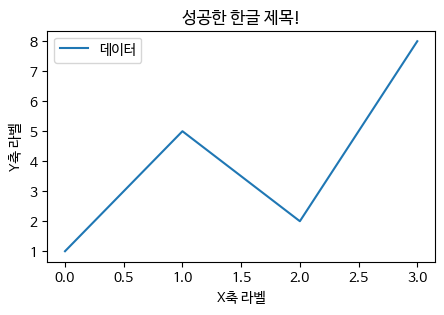

In [3]:
# 그래프 한글 표시 테스트
plt.figure(figsize=(5, 3))
plt.title('성공한 한글 제목!')
plt.xlabel('X축 라벨')
plt.ylabel('Y축 라벨')
plt.plot([1, 5, 2, 8], label='데이터')
plt.legend()
plt.show()

# 2.문서를 시기별로 구분

In [4]:
# 통합 데이터 불러오기
df = pd.read_excel(file_path + 'result/gb_data_2(doc,1g2g,wn_cls).xlsx') ###
print(df.shape)
df[:3]

(6802, 9)


,doc_id,doc_raw,doc_split_12gram,r_no,title,w_new,ho_no,grid_1,wn_cls
0,1,創刊辭 强者도 부르짖고 弱者도 부르짖으며 優者도 부르짖고 劣者도 부르짖도다 東西南北...,창간 辭 강자 약자 優者 劣者 동서 남북 사해 팔방 소리 소리 판단 좌우 間 다수 ...,1,創刊辭,uk01,1,01q,0
1,2,哲人은 말하되 多數 人民의 聲은 곳 神의 聲이라 하엿나니 神은 스스로 要求가 없는지...,哲人 다수 인민 요구 인민 소리 요구 발표 갈앙 인민 소리 갈앙 다수 인민 갈앙 요...,1,創刊辭,uk01,1,01q,0
2,3,世界를 알라 사람은 天使도 안이며 野獸도 안이오 오즉 사람일 뿐이로다 이만치 進化된...,세계 사람 야수 사람 진화 진화 지식 진화 도덕 동물 세계 천당 지옥 세계 진화 국...,2,世界를 알라,uk01,1,01q,0


In [5]:
# 1기와 2기의 경계 확인
df.query('grid_1 == "10q"')[-3:]

,doc_id,doc_raw,doc_split_12gram,r_no,title,w_new,ho_no,grid_1,wn_cls
3042,3043,推倒迂晦的 難澁的 山林文學 建設明瞭的 通俗的 社會文學이라하고 該論 最末에 有不顧迂儒...,문학 산림 건설 명료 통속 사회 문학 대포 新 문학 革設 人的 문학 저작 過去 문학...,149,"現中國의 舊思想, 舊文藝의 改革으로부터 新東洋文化의 樹立에 他山의 石으로 現中國의 ...",이동곡,30,10q,3
3043,3044,如斯히 新文學建設의 운동이 急轉直下的으로 진보되는 때에 그 문학계의 牛耳를 執한 이...,건설 문학 新 운동 직하 급전 진보 문학 진독수 지식 혁명 家 본색 주장 견식 논의...,149,"現中國의 舊思想, 舊文藝의 改革으로부터 新東洋文化의 樹立에 他山의 石으로 現中國의 ...",이동곡,30,10q,3
3044,3045,그리하야 미국式의 민주주의思想派 社會主義派 又는 無政府主義派 기타 色別의 思想派가 ...,미국 민주_主義 사상 派 사회_主義 派 無_정부 정부_主義 派 사상 무수 민주_主義...,149,"現中國의 舊思想, 舊文藝의 改革으로부터 新東洋文化의 樹立에 他山의 石으로 現中國의 ...",이동곡,30,10q,3


In [6]:
# 1기와 2기의 경계 확인
df.query('grid_1 == "11q"')[:3]

,doc_id,doc_raw,doc_split_12gram,r_no,title,w_new,ho_no,grid_1,wn_cls
3045,3046,汎人間的 民族主義 主義와 主義 인류와 인류가 서로 석기어 살메 미처 가장 능히 人類...,인간 汎 민족_主義 主義 主義 인류 인류 인류 自己 意識 힘 발휘 자아 생활 자아 ...,150,汎人間的 民族主義,uk06,31,11q,0
3046,3047,자기생활에 대한 이해타산의 관념은 卑近한 곳으로 원대함에 나아가고 불완전으로부터 완...,생활 利害 타산 관념 비근 완전 완전 인류_생활 최초 意識 主義 利己 형식 타산 利...,150,汎人間的 民族主義,uk06,31,11q,0
3047,3048,思컨대 금일의 사상계는 민족주의와 인류주의의 兩對 倂立을 보게 되엇나니 민족주의가 ...,금일 사상 민족_主義 인류_主義 민족_主義 생활 타산 利害 민족 인류_主義 인류 전...,150,汎人間的 民族主義,uk06,31,11q,0


In [7]:
# 전기,후기: doc_id는 3046부터 끝까지
df['period'] = np.where(
    df['doc_id'] < 3046,  # 조건
    'p1',                          # 조건이 참일 때
    'p2'                           # 조건이 거짓일 때
)
df

,doc_id,doc_raw,doc_split_12gram,r_no,title,w_new,ho_no,grid_1,wn_cls,period
0,1,創刊辭 强者도 부르짖고 弱者도 부르짖으며 優者도 부르짖고 劣者도 부르짖도다 東西南北...,창간 辭 강자 약자 優者 劣者 동서 남북 사해 팔방 소리 소리 판단 좌우 間 다수 ...,1,創刊辭,uk01,1,01q,0,p1
1,2,哲人은 말하되 多數 人民의 聲은 곳 神의 聲이라 하엿나니 神은 스스로 要求가 없는지...,哲人 다수 인민 요구 인민 소리 요구 발표 갈앙 인민 소리 갈앙 다수 인민 갈앙 요...,1,創刊辭,uk01,1,01q,0,p1
2,3,世界를 알라 사람은 天使도 안이며 野獸도 안이오 오즉 사람일 뿐이로다 이만치 進化된...,세계 사람 야수 사람 진화 진화 지식 진화 도덕 동물 세계 천당 지옥 세계 진화 국...,2,世界를 알라,uk01,1,01q,0,p1
3,4,사람과 世界는 決코 논하볼 것이 안이엇다 사람으로 된 世界 世界로 된 사람 둘이 안...,사람 세계 사람 세계 세계 사람 세계 대표 시대 가치 사람 대표 문화 상징 符號 사...,2,世界를 알라,uk01,1,01q,0,p1
4,5,過去는 論할 것이 업도다만은 今日과 가티 交通이 이마마하고 知識이 이마마하고 一切의...,過去 금일 교통 지식 일체 문물 오늘 세계 理解 공자 천하 천하 理解 오늘 날 사람...,2,世界를 알라,uk01,1,01q,0,p1
...,...,...,...,...,...,...,...,...,...,...
6797,6798,미국에서는 每人에게 奴僕이 식 돌아감니다 단 機械奴僕만 이건 무슨 말이냐 하면 기계...,미국 노복 機械 노복 機械 力 운전 계산 人力 계산 미국 국민 사람 機械 輸入 숫자...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6798,6799,매년 저축은ㅡ필요의 비용을 다 쓴 뒤의 것 말이지요ㅡ매년에 억 딸라 金 루불로는 억...,저축 필요 비용 미국 교과 書 실상 미국 富豪 캐나다 영국 미국 부분 미국 캐나다 ...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6799,6800,그러고 또 캐나다는 아조 겸손스럽게 좀 유순하게 미국의 北邊繼續이라고ㅡ국제연맹의 축...,캐나다 미국 국제_연맹 국제_연맹 원인 경제 機械 캐나다 산업 북미 자본 점령 부분...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6800,6801,25년 전에는 영국이 美보다 배나 더 되게 輸入하엿섯음니다 캐나다 사람들은 지금 그...,영국 미국 輸入 캐나다 사람 영국 一部 미국 호주 캐나다 진화 호주 일본 침입 보호...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2


In [8]:
# 시기구분 정보 확인 코드
df.groupby(['period', 'grid_1'])['doc_id'].count()

period  grid_1
p1      01q       193
        02q       223
        03q       296
        04q       292
        05q       435
        06q       333
        07q       410
        08q       413
        09q       152
        10q       298
p2      11q       315
        12q       261
        13q       198
        14q       393
        15q       456
        16q       254
        17q       154
        18q       201
        19q       223
        20q       224
        21q       226
        22q       248
        23q       324
        24q       280
Name: doc_id, dtype: int64

# 3.2기의 주요 필자 현황

## 3.1.필자 그룹 확인
- 통합 데이터의 'wn_cls' 정보 확인
- 0: 필자 미상
- 1: 개벽 주도층 - 김기전, 박달성, 이돈화, 차상찬
- 2: 사회주의 필자 <- 기존 연구에 의함
- 3: 기타 - 0~2 이외

In [9]:
# df 현황
print(df.shape)
df.head(3)

(6802, 10)


,doc_id,doc_raw,doc_split_12gram,r_no,title,w_new,ho_no,grid_1,wn_cls,period
0,1,創刊辭 强者도 부르짖고 弱者도 부르짖으며 優者도 부르짖고 劣者도 부르짖도다 東西南北...,창간 辭 강자 약자 優者 劣者 동서 남북 사해 팔방 소리 소리 판단 좌우 間 다수 ...,1,創刊辭,uk01,1,01q,0,p1
1,2,哲人은 말하되 多數 人民의 聲은 곳 神의 聲이라 하엿나니 神은 스스로 要求가 없는지...,哲人 다수 인민 요구 인민 소리 요구 발표 갈앙 인민 소리 갈앙 다수 인민 갈앙 요...,1,創刊辭,uk01,1,01q,0,p1
2,3,世界를 알라 사람은 天使도 안이며 野獸도 안이오 오즉 사람일 뿐이로다 이만치 進化된...,세계 사람 야수 사람 진화 진화 지식 진화 도덕 동물 세계 천당 지옥 세계 진화 국...,2,世界를 알라,uk01,1,01q,0,p1


In [10]:
# 필자 그룹별 논설 수 정보 확인

## 필요한 컬럼 선택
rons = df[['r_no', 'title', 'w_new', 'ho_no', 'grid_1','wn_cls', 'period']]
# r_no 기준으로 중복 제거 (논설 고유 기준)
ron_original = rons.drop_duplicates(subset='r_no')

# 필자 그룹(w_cls)별 논설 수 집계
#writer_group_count = ron_original.groupby('wn_cls')['r_no'].count()

# 1,2기별 구분
writer_group_count_period = ron_original.pivot_table(
    index='wn_cls',
    columns='period',
    values='r_no',
    aggfunc='count'
)
writer_group_count_period

period,p1,p2
wn_cls,,
0,34,51
1,59,32
2,2,44
3,54,58


In [11]:
# 논설/필자 현황
print(ron_original.shape)
ron_original.head(3)

(334, 7)


,r_no,title,w_new,ho_no,grid_1,wn_cls,period
0,1,創刊辭,uk01,1,01q,0,p1
2,2,世界를 알라,uk01,1,01q,0,p1
22,3,時急히 解決할 朝鮮의 二大問題,박달성,1,01q,1,p1


## 3.2.2기 구간별/그룹별 필자 및 논설 수

In [12]:
# 2기 논설별 필자 1,2그룹 정보
ron_12gp = ron_original.query('period == "p2" and (wn_cls == 1 or wn_cls == 2)')
ron_12gp_idx = ron_12gp.set_index('r_no')
print(ron_12gp_idx.shape)
ron_12gp_idx

(76, 6)


,title,w_new,ho_no,grid_1,wn_cls,period
r_no,,,,,,
157,"第一의 解放과 第二의 解放, 人類歷史上의 二大解放宣言",김기전,32,11q,1,p2
160,"農民運動國産運動이 勃發하기까지, (餓鬼의 威壓에서 解放되려하는 民衆運動의 二三)",김기전,32,11q,1,p2
174,開闢運動과 合致되는 朝鮮의 少年運動,김기전,35,12q,1,p2
180,깐듸의 運動과 印度의 無産階級,이성태,37,13q,2,p2
185,新文學 建設과 한글 整理,양명,38,13q,2,p2
...,...,...,...,...,...,...
325,"朝鮮思想運動者들의 階級的組成을 推究하면서, 朝鮮의 熟慮",박진순,71,24q,2,p2
327,近世植民政策의 終幕(近世植民政策의 起源과 由來其三),박형병,71,24q,2,p2
329,士禍와 黨爭,차상찬,71,24q,1,p2


In [13]:
import pandas as pd

# 필요한 컬럼만 추출
df_subset = ron_12gp_idx[['grid_1', 'w_new', 'wn_cls']]

# 논설 수 세기
author_counts = df_subset.groupby(['grid_1', 'wn_cls', 'w_new']).size().reset_index(name='count')

# 필자명(개수) 형태로 문자열 결합
author_counts['entry'] = author_counts['w_new'] + '(' + author_counts['count'].astype(str) + ')'

# 각 grid_1별 wn_cls 그룹을 하나의 문자열로 묶기
pivot_table = author_counts.groupby(['grid_1', 'wn_cls'])['entry'].apply(', '.join).reset_index()

# 가독성을 위해 wn_cls 값 → 텍스트로 변환
wn_cls_map = {1: '개벽 주도층', 2: '사회주의자'}
pivot_table['wn_cls'] = pivot_table['wn_cls'].map(wn_cls_map)

# 최종 형태로 피벗
final_table = pivot_table.pivot(index='grid_1', columns='wn_cls', values='entry').fillna('')

# 정렬
final_table = final_table.sort_index()

# 출력
final_table

wn_cls,개벽 주도층,사회주의자
grid_1,,
11q,김기전(2),
12q,김기전(1),
13q,,"양명(1), 이성태(2), 주종건(1)"
14q,박달성(1),"김기진(1), 정지현(1), 주종건(1)"
15q,"김기전(2), 이돈화(1)","O民(1), 김기진(1), 양명(1), 이성태(1), 정지현(2)"
16q,"김기전(1), 이돈화(1)",
17q,"박달성(1), 이돈화(2), 차상찬(1)","박헌영(1), 이성태(1)"
18q,이돈화(1),"김경재(1), 이성태(1), 정지현(1)"
19q,"김기전(2), 박달성(1), 이돈화(2)","김경재(1), 김기진(1), 김명식(1), 박형병(1), 정지현(1)"


# 4.2기 필자별 토픽 분포
- 연구질문의 초점: 2기 주요 필자 그룹별 사회주의 토픽
- 2기 주요 필자별 문서 데이터 호출 -> 저장한 모델로 문서별 토픽 분포 산출 -> 2기 필자 그룹별 문서 부분만 남김

## 4.1.(A) 2기 주요 필자별 문서 호출

In [14]:
# ron_gp_idx(2기 논설별 필자 1,2그룹) 를 문서별 정보로 출력
ron_12gp_idx.index # 논설 인덱스 정보
doc_12gp_idx = df[df['r_no'].isin(ron_12gp_idx.index)].set_index('doc_id')
doc_12gp_idx

,doc_raw,doc_split_12gram,r_no,title,w_new,ho_no,grid_1,wn_cls,period
doc_id,,,,,,,,,
3218,第一의 解放과 第二의 解放 人類歷史上의 二大解放宣言 인류의 역사는 解放의 역사라 한...,해방 해방 역사 인류 인류 역사 해방 역사 역사 해방 역사 해방 바다 역사 세간 내...,157,"第一의 解放과 第二의 解放, 人類歷史上의 二大解放宣言",김기전,32,11q,1,p2
3219,그 하나는 우리들의 공동생활의 사실로브터 스스로 민중의 새에서 발달되여진 人類連帶相...,공동 생활 민중 발달 相互 인류 扶助 連帶 소수 者 武力 지위 이익 확보 다수 민중...,157,"第一의 解放과 第二의 解放, 人類歷史上의 二大解放宣言",김기전,32,11q,1,p2
3220,프랑스의 혁명 때에 聲明된 人權宣言 그 선언서는 년 월 일 프랑스 立憲議會의 發布한...,프랑스_혁명 聲明 선언 인권 선언 書 프랑스 입헌 의회 발포 프랑스 헌법 사람 자유...,157,"第一의 解放과 第二의 解放, 人類歷史上의 二大解放宣言",김기전,32,11q,1,p2
3221,말하면 今日 일본의 헌법도 미리부터 그 風下에 서서 뚜렷하지 못하나마 그것의 제 장...,금일 일본 헌법 권리 규정 인권 선언 영향 법률 실시 민중_운동 폭군 전횡 특권_계...,157,"第一의 解放과 第二의 解放, 人類歷史上의 二大解放宣言",김기전,32,11q,1,p2
3222,그때의 인권옹호론자는 사람이라는 稱語 밋헤 남자뿐을 포함케 함으로써 족음 異常하게 ...,인권 옹호 논자 사람 남자 포함 異常 인권 선언 의미 인권 선언 선언 포함 선언 포...,157,"第一의 解放과 第二의 解放, 人類歷史上의 二大解放宣言",김기전,32,11q,1,p2
...,...,...,...,...,...,...,...,...,...
6798,미국에서는 每人에게 奴僕이 식 돌아감니다 단 機械奴僕만 이건 무슨 말이냐 하면 기계...,미국 노복 機械 노복 機械 力 운전 계산 人力 계산 미국 국민 사람 機械 輸入 숫자...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6799,매년 저축은ㅡ필요의 비용을 다 쓴 뒤의 것 말이지요ㅡ매년에 억 딸라 金 루불로는 억...,저축 필요 비용 미국 교과 書 실상 미국 富豪 캐나다 영국 미국 부분 미국 캐나다 ...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2
6800,그러고 또 캐나다는 아조 겸손스럽게 좀 유순하게 미국의 北邊繼續이라고ㅡ국제연맹의 축...,캐나다 미국 국제_연맹 국제_연맹 원인 경제 機械 캐나다 산업 북미 자본 점령 부분...,334,유로빠와 아메리카(一) 금년 봄에 모쓰크바 엑쓰페리멘탈 劇場에서 한 「트로츠끼」의 講演.,김철산,72,24q,2,p2


## 4.2.(B) 문서별 토픽 분포 산출
- 저장한 모델 호출

In [15]:
#모델 불러오기 + 메타데이터(구간정보) 출력
model = DMRModel.load(file_path + 'result/gb_n_dmr_model(k=8,seed=7,0.05,0.1).bin')
model.metadata_dict

['01q', '02q', '03q', '04q', '05q', '06q', '07q', '08q', '09q', '10q', '11q', '12q', '13q', '14q', '15q', '16q', '17q', '18q', '19q', '20q', '21q', '22q', '23q', '24q']

In [16]:
model.summary(topic_word_top_n=20)

<Basic Info>
| DMRModel (current version: 0.13.0)
| 6802 docs, 257159 words
| Total Vocabs: 5828, Used Vocabs: 5828
| Entropy of words: 7.43552
| Entropy of term-weighted words: 7.43552
| Removed Vocabs: <NA>
| Metadata of docs and its distribution
|  01q: 193
|  02q: 223
|  03q: 296
|  04q: 292
|  05q: 435
|  06q: 333
|  07q: 410
|  08q: 413
|  09q: 152
|  10q: 298
|  11q: 315
|  12q: 261
|  13q: 198
|  14q: 393
|  15q: 456
|  16q: 254
|  17q: 154
|  18q: 201
|  19q: 223
|  20q: 224
|  21q: 226
|  22q: 248
|  23q: 324
|  24q: 280
|
<Training Info>
| Iterations: 1000, Burn-in steps: 0
| Optimization Interval: 10
| Log-likelihood per word: -7.60149
|
<Initial Parameters>
| tw: TermWeight.ONE
| min_cf: 0 (minimum collection frequency of words)
| min_df: 0 (minimum document frequency of words)
| rm_top: 0 (the number of top words to be removed)
| k: 8 (the number of topics between 1 ~ 32767)
| alpha: [0.05] (an initial value of exponential of mean of normal distribution for `lambdas`, giv

In [17]:
# 문서별 토픽 분포 산출

'''save topic dist per doc
output: docs_dist.txt'''

f = open(file_path + 'result/doc-distrib.txt', 'w', encoding='utf-8') ### 저정 파일 이름 지정

k = 8  ###

# calculate topic distribution
doc_topic_dists = np.stack([doc.get_topic_dist() for doc in model.docs])
doc_topic_dists /= doc_topic_dists.sum(axis=1, keepdims=True)


dn = 1
for i in range(k):
    f.write('\tT{}'.format(i))
f.write('\n')

for i in doc_topic_dists:
    #print('D'+str(dn), i)
    f.write("{}".format(str(dn)))
    for d in range(k): #토픽수
        f.write("\t{:.8f}".format(i[d]))
    f.write('\n')

    dn += 1
print('Topic distributions per docs')
f.close()

Topic distributions per docs


In [18]:
# 데이터프레임으로 변환

def create_dataframe_from_text(data: str) -> pd.DataFrame:
    """
    텍스트 데이터를 파싱하여 pandas DataFrame으로 변환. 첫 열은 행 번호로 처리.
    Parameters:
        data (str): 텍스트 형식의 데이터 (탭과 줄바꿈으로 구분).
    Returns:
        pd.DataFrame: 데이터프레임으로 변환된 결과.
    """
    # 텍스트 데이터를 줄 단위로 분리
    lines = data.strip().split("\n")

    # 첫 줄은 헤더로 사용
    header = lines[0].strip().split("\t")

    # 나머지 줄은 데이터로 처리
    rows = [line.strip().split("\t") for line in lines[1:]]

    # 데이터프레임 생성
    df = pd.DataFrame(rows, columns=["doc_id"] + header)

    # 첫 열(Index)을 인덱스로 설정하고 제거
    #df.set_index("Index", inplace=True)

    # 숫자형 데이터로 변환
    df = df.apply(pd.to_numeric)

    return df

## 4.3.(A+B) 2기 필자별 토픽 분포
- 2기 문서-토픽 분포 -> 주요 필자별 문서-토픽 분포

In [20]:
# 2기 문서 토픽 분포만 추출
with open(file_path + 'result/doc-distrib.txt', 'r', encoding='utf-8') as file:
    text_data = file.read()

# 함수 호출
temp = create_dataframe_from_text(text_data).set_index('doc_id')
p2_idx = [idx for idx in temp.index if idx >= 3046] ###
p2_idx
doc_dist_idx = temp.loc[p2_idx]
doc_dist_idx

,T0,T1,T2,T3,T4,T5,T6,T7
doc_id,,,,,,,,
3046,0.024014,0.000267,0.003974,0.003170,0.569556,0.333536,0.062998,0.002487
3047,0.257124,0.011219,0.002259,0.012869,0.578269,0.134242,0.002606,0.001414
3048,0.196461,0.000204,0.032722,0.002417,0.716339,0.001928,0.003496,0.046434
3049,0.271844,0.000262,0.003898,0.079506,0.635074,0.002480,0.004497,0.002440
3050,0.406589,0.000184,0.002745,0.029086,0.406833,0.001746,0.003166,0.149650
...,...,...,...,...,...,...,...,...
6798,0.003296,0.014734,0.604653,0.085668,0.000684,0.001389,0.163286,0.126290
6799,0.004578,0.020463,0.062022,0.007873,0.000949,0.001929,0.449007,0.453179
6800,0.003746,0.016743,0.232563,0.051896,0.000777,0.001578,0.003735,0.688963


In [21]:
# 주요 필자별 문서-토픽 분포
doc_dist_12 = doc_dist_idx.loc[doc_12gp_idx.index,:]
doc_dist_12

,T0,T1,T2,T3,T4,T5,T6,T7
doc_id,,,,,,,,
3218,0.067180,0.000747,0.011117,0.662519,0.231581,0.007073,0.012825,0.006958
3219,0.024491,0.000272,0.004053,0.380528,0.382289,0.002578,0.004676,0.201113
3220,0.003802,0.000223,0.003326,0.002653,0.623411,0.002116,0.036433,0.328036
3221,0.005641,0.000331,0.004935,0.028115,0.610552,0.027318,0.005693,0.317414
3222,0.006417,0.000377,0.005613,0.334525,0.639507,0.003571,0.006476,0.003513
...,...,...,...,...,...,...,...,...
6798,0.003296,0.014734,0.604653,0.085668,0.000684,0.001389,0.163286,0.126290
6799,0.004578,0.020463,0.062022,0.007873,0.000949,0.001929,0.449007,0.453179
6800,0.003746,0.016743,0.232563,0.051896,0.000777,0.001578,0.003735,0.688963


In [22]:
# 필요정보 결합
dist_writer_12 = pd.concat([doc_dist_12, doc_12gp_idx[['w_new', 'wn_cls']]], axis=1)
dist_writer_12

,T0,T1,T2,T3,T4,T5,T6,T7,w_new,wn_cls
doc_id,,,,,,,,,,
3218,0.067180,0.000747,0.011117,0.662519,0.231581,0.007073,0.012825,0.006958,김기전,1
3219,0.024491,0.000272,0.004053,0.380528,0.382289,0.002578,0.004676,0.201113,김기전,1
3220,0.003802,0.000223,0.003326,0.002653,0.623411,0.002116,0.036433,0.328036,김기전,1
3221,0.005641,0.000331,0.004935,0.028115,0.610552,0.027318,0.005693,0.317414,김기전,1
3222,0.006417,0.000377,0.005613,0.334525,0.639507,0.003571,0.006476,0.003513,김기전,1
...,...,...,...,...,...,...,...,...,...,...
6798,0.003296,0.014734,0.604653,0.085668,0.000684,0.001389,0.163286,0.126290,김철산,2
6799,0.004578,0.020463,0.062022,0.007873,0.000949,0.001929,0.449007,0.453179,김철산,2
6800,0.003746,0.016743,0.232563,0.051896,0.000777,0.001578,0.003735,0.688963,김철산,2


In [23]:
# 필자별-문서별 토픽 분포 결과 저장
dist_writer_12.to_excel(file_path + 'result/dist_writer_12.xlsx')

In [24]:
# 필자별 토픽 분포

wdist_writer_12 = dist_writer_12.groupby('w_new').mean()
wdist_writer_12['wn_cls'] = wdist_writer_12['wn_cls'].astype(int)
wdist_writer_12

,T0,T1,T2,T3,T4,T5,T6,T7,wn_cls
w_new,,,,,,,,,
O民,0.148086,0.005180,0.142894,0.444095,0.015698,0.065906,0.069980,0.108160,2
김경재,0.039826,0.004068,0.338403,0.257704,0.077542,0.069232,0.176926,0.036297,2
김기전,0.062011,0.057159,0.050260,0.181798,0.132868,0.060115,0.273427,0.182362,1
김기진,0.075177,0.003369,0.020807,0.376734,0.067592,0.216093,0.193401,0.046827,2
김명식,0.189031,0.031495,0.078008,0.282802,0.084365,0.092780,0.078226,0.163293,2
김철산,0.024602,0.019443,0.212773,0.255045,0.001908,0.084710,0.105019,0.296500,2
박달성,0.029333,0.020161,0.322111,0.051988,0.076018,0.058096,0.413946,0.028347,1
박영희,0.425444,0.000704,0.055550,0.049422,0.060271,0.386822,0.011952,0.009835,2
박진순,0.081250,0.036364,0.083530,0.598985,0.036911,0.042440,0.062667,0.057854,2


In [25]:
# 필자별 토픽 분포 결과 저장
wdist_writer_12.to_excel(file_path + 'result/wdist_writer_12.xlsx')

# 5.2기 필자 그룹 간 차이 파악
- 개벽주도층(분류 1) vs 사회주의자(분류 2)
- 비교항목: 사회주의 토픽(T3)

## 5.1.상자그림: 직관적 확인

In [26]:
group_11 = wdist_writer_12[wdist_writer_12['wn_cls'] == 1]['T3']  # 개벽 주도층
group_22 = wdist_writer_12[wdist_writer_12['wn_cls'] == 2]['T3']  # 사회주의자

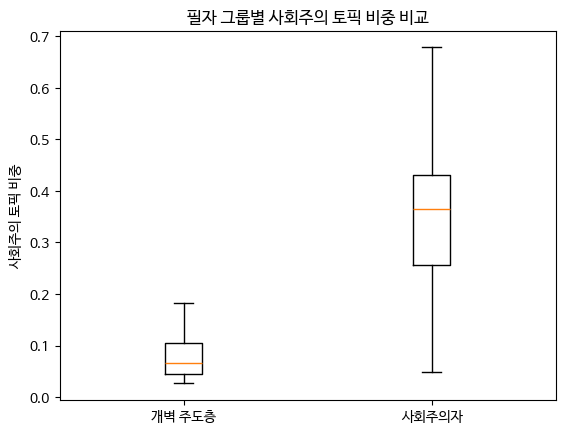

In [27]:
import matplotlib.pyplot as plt

# 박스플롯
plt.boxplot([group_11, group_22], tick_labels=['개벽 주도층', '사회주의자'])
plt.title('필자 그룹별 사회주의 토픽 비중 비교')
plt.ylabel('사회주의 토픽 비중')
plt.show()

In [28]:
print(f"Group 1 Median (개벽 주도층): {group_11.median()}")
print(f"Group 2 Median (사회주의자): {group_22.median()}")

Group 1 Median (개벽 주도층): 0.0660777199512987
Group 2 Median (사회주의자): 0.36423081912162164


## 5.2.가설검정: 통계적 확인

### 정규성 검정

In [29]:
# 정규성 검정: 각 그룹의 T3 데이터가 정규 분포를 따르는지 검정합니다.

from scipy.stats import shapiro

# 정규성 검정
stat1, p1 = shapiro(group_11)
stat2, p2 = shapiro(group_22)

print(f"Group 11 (개벽 주도층): p-value={p1}")
print(f"Group 22 (사회주의자): p-value={p2}")

Group 11 (개벽 주도층): p-value=0.3978279095724942
Group 22 (사회주의자): p-value=0.937027601317698


**해석**
- Shapiro-Wilk 검정의 귀무가설(H0)은 “데이터가 정규분포를 따른다.”임.
- 따라서 p-value가 0.05보다 작으면 귀무가설을 기각하고, 정규분포가 아니라고 판단함.
- 그런데 Group11과 Group22의 p-value가 모두 0.05보다 크다.  
- 따라서 정규성을 전제로 한 검정(T-test)를 진행해도 됨.

### 등분산성 검정

In [30]:
# 등분산성 검정(Levene's test)

from scipy.stats import levene

stat, p_var = levene(group_11, group_22)
print(f"등분산 검정 p-value: {p_var}")

등분산 검정 p-value: 0.15217068275867437


p-value > 0.05 이므로 귀무가설을 기각할 수 없음.따라서 **"두 집단의 분산은 같다"**고 결론 내릴 수 있음.  
최종 결론: 등분산성 가정이 충족되었으므로, 이후 t-test를 진행할 때 Student's t-test 방법을 사용하면 됨 -> scipy 라이브러리의 ttest_ind 함수에서는 equal_var=True 옵션을 설정하는 것에 해당(이것이 기본값).

### T-test
- 두 그룹의 평균이 통계적으로 다르다고 말할 수 있는지 확인하는 방법

In [31]:
from scipy.stats import ttest_ind

stat, p = ttest_ind(group_11, group_22, equal_var=True) # equal_var 등분산 가정 여부
print(f"T-test p-value: {p}")

T-test p-value: 0.007995876827609416


**[해석]**
- T-test의 귀무가설은 "차이가 없다"이다.
- T-test의 p-value는 0.00423으로 이 값은 0.05보다 작으므로 귀무가설을 기각한다.
- 따라서 두 그룹의 평균이 통계적으로 유의미하게 다르다고 할 수 있다.

# The End of Notebook